In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score


file_path = 'T1.csv'
data = pd.read_csv(file_path)


data.head(), data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50530 entries, 0 to 50529
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date/Time                      50530 non-null  object 
 1   LV ActivePower (kW)            50530 non-null  float64
 2   Wind Speed (m/s)               50530 non-null  float64
 3   Theoretical_Power_Curve (KWh)  50530 non-null  float64
 4   Wind Direction (°)             50530 non-null  float64
dtypes: float64(4), object(1)
memory usage: 1.9+ MB


(          Date/Time  LV ActivePower (kW)  Wind Speed (m/s)  \
 0  01 01 2018 00:00           380.047791          5.311336   
 1  01 01 2018 00:10           453.769196          5.672167   
 2  01 01 2018 00:20           306.376587          5.216037   
 3  01 01 2018 00:30           419.645905          5.659674   
 4  01 01 2018 00:40           380.650696          5.577941   
 
    Theoretical_Power_Curve (KWh)  Wind Direction (°)  
 0                     416.328908          259.994904  
 1                     519.917511          268.641113  
 2                     390.900016          272.564789  
 3                     516.127569          271.258087  
 4                     491.702972          265.674286  ,
 None)

(169505.14196548512,
 0.9006599245385882,
 160895.94627969197,
 0.9057054242748906)

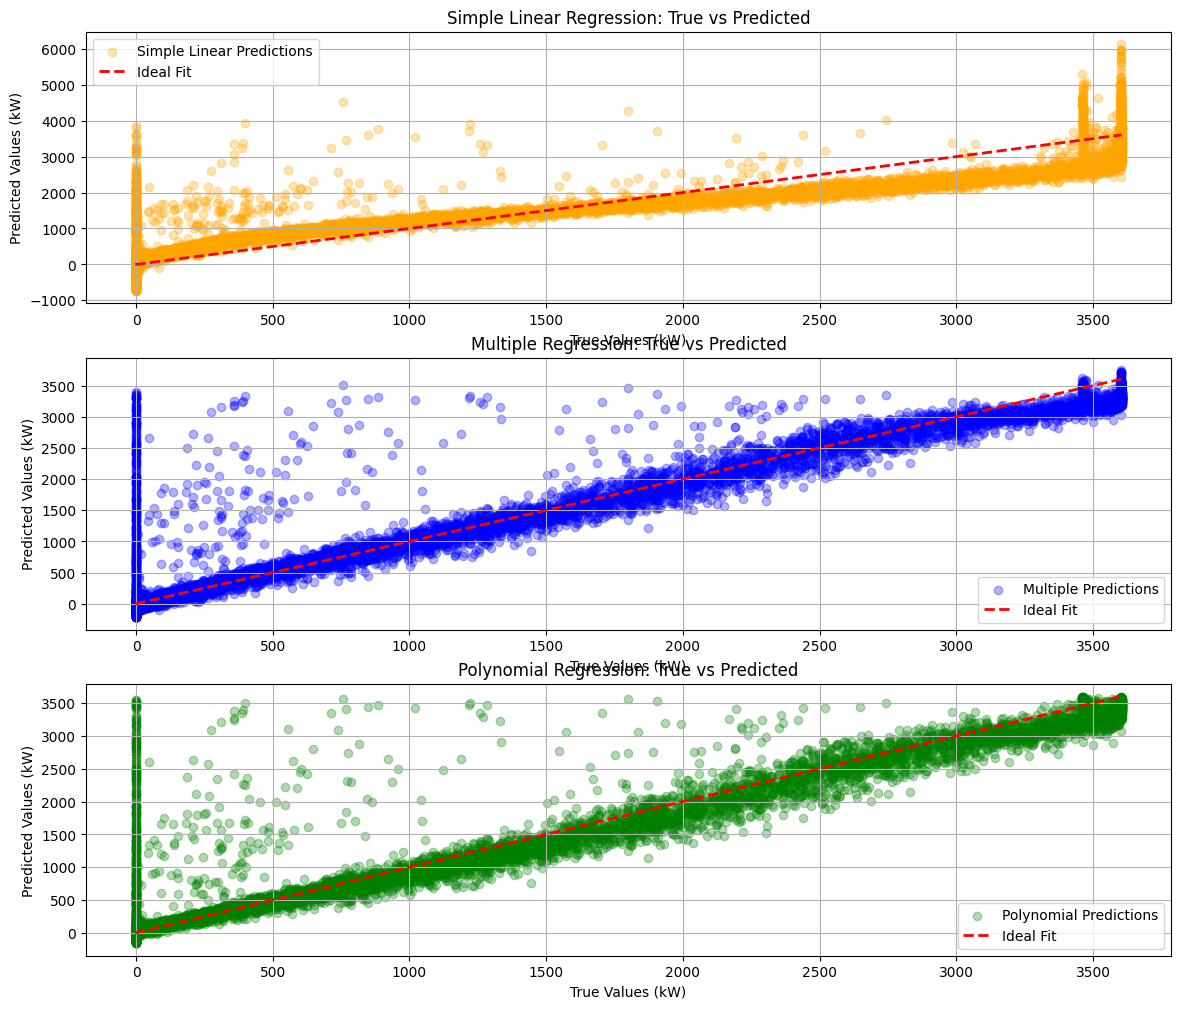

In [9]:
X = data[['Wind Speed (m/s)', 'Theoretical_Power_Curve (KWh)', 'Wind Direction (°)']]
y = data['LV ActivePower (kW)']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_single = data[['Wind Speed (m/s)']]
X_train_single, X_test_single, y_train_single, y_test_single = train_test_split(X_single, y, test_size=0.2, random_state=42)

simple_linear_model = LinearRegression()
simple_linear_model.fit(X_train_single, y_train_single)
simple_linear_preds = simple_linear_model.predict(X_test_single)

simple_linear_mse = mean_squared_error(y_test_single, simple_linear_preds)
simple_linear_r2 = r2_score(y_test_single, simple_linear_preds)


linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_preds = linear_model.predict(X_test)


linear_mse = mean_squared_error(y_test, linear_preds)
linear_r2 = r2_score(y_test, linear_preds)


poly_features = PolynomialFeatures(degree=2)
X_poly_train = poly_features.fit_transform(X_train)
X_poly_test = poly_features.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_poly_train, y_train)
poly_preds = poly_model.predict(X_poly_test)

poly_mse = mean_squared_error(y_test, poly_preds)
poly_r2 = r2_score(y_test, poly_preds)


plt.figure(figsize=(14, 12))

plt.subplot(3, 1, 1)
plt.scatter(y_test_single, simple_linear_preds, alpha=0.3, color="orange", label="Simple Linear Predictions")
plt.plot([y_test_single.min(), y_test_single.max()], [y_test_single.min(), y_test_single.max()], 'r--', lw=2, label="Ideal Fit")
plt.title("Simple Linear Regression: True vs Predicted")
plt.xlabel("True Values (kW)")
plt.ylabel("Predicted Values (kW)")
plt.legend()
plt.grid(True)


plt.subplot(3, 1, 2)
plt.scatter(y_test, linear_preds, alpha=0.3, color="blue", label="Multiple Predictions")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label="Ideal Fit")
plt.title("Multiple Regression: True vs Predicted")
plt.xlabel("True Values (kW)")
plt.ylabel("Predicted Values (kW)")
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 3)
plt.scatter(y_test, poly_preds, alpha=0.3, color="green", label="Polynomial Predictions")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label="Ideal Fit")
plt.title("Polynomial Regression: True vs Predicted")
plt.xlabel("True Values (kW)")
plt.ylabel("Predicted Values (kW)")
plt.legend()
plt.grid(True)

plt.show()

In [6]:
from sklearn.neighbors import KNeighborsRegressor


knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_preds = knn_model.predict(X_test)

knn_mse = mean_squared_error(y_test, knn_preds)



print("K-Nearest Neighbors Regression:")
print(f": {knn_mse}")



plt.figure(figsize=(7, 6))
plt.scatter(y_test, knn_preds, alpha=0.3, color="purple", label="KNN Predictions")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label="Ideal Fit")
plt.title("K-Nearest Neighbors Regression: True vs Predicted")
plt.xlabel("True Values (kW)")
plt.ylabel("Predicted Values (kW)")
plt.legend()
plt.grid(True)
plt.show()


NameError: name 'mean_squared_error' is not defined

In [12]:
linear_model.score(X_test,y_test)

0.9006599245385882

In [14]:
poly_model.score(X_poly_test,y_test)

0.9057054242748906